# EMG Preprocessing Pipeline
## NinaPro DB1 — Subject 1, Exercise 1

---

**What is this notebook?**  
This notebook walks through the complete preprocessing pipeline for EMG (Electromyography) data from the NinaPro DB1 dataset. We work with data from **1 subject, 12 hand gestures, 10 forearm muscle channels**.

**The 4 steps we follow:**
1. Load and understand the raw `.mat` file
2. Visualise the raw EMG signal
3. Preprocess: Bandpass Filter → Rectify → RMS Envelope
4. Segment by gesture label and visualise per-gesture activation

---

## Cell 1 — Import Libraries

Before doing anything, we import all the tools we'll need:

| Library | Purpose |
|---|---|
| `numpy` | All mathematical operations on arrays |
| `scipy.io` | Reading `.mat` files (MATLAB format) |
| `scipy.signal` | Signal processing — filters |
| `matplotlib` | Plotting graphs |
| `os` | File and folder management |

In [1]:
import numpy as np
import scipy.io as sio
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
import os

# Makes plots appear inside the notebook
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## Cell 2 — Configuration

Set all file paths and constants in one place.  
If you ever change the file location, you only need to update this cell.

**Key constant — Sampling Rate (FS = 100 Hz):**  
NinaPro DB1 records 100 samples per second per channel.  
So if you have 101,014 samples, that's `101,014 / 100 = 1010 seconds ≈ 16.8 minutes` of recording.

In [2]:
# ── File Paths ──────────────────────────────────────────────
MAT_FILE   = '/Users/dewansh/Documents/Summer/HandsOn/s1/S1_A1_E1.mat'
OUTPUT_DIR = '/Users/dewansh/Documents/Summer/HandsOn/output/emg'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Signal Parameters ───────────────────────────────────────
FS = 100           # Sampling rate: 100 samples per second
WINDOW_MS = 200    # RMS window size: 200 milliseconds
WINDOW_SAMPLES = int(FS * WINDOW_MS / 1000)   # = 20 samples

# ── Gesture Labels (Exercise 1 has 12 gestures) ─────────────
# The 'stimulus' column in the data uses these integer codes
GESTURE_NAMES = {
    0:  'Rest',
    1:  'Small Finger Flexion',
    2:  'Ring Finger Flexion',
    3:  'Middle Finger Flexion',
    4:  'Index Finger Flexion',
    5:  'Thumb Flexion',
    6:  'Thumb + Index (Pinch)',
    7:  'Thumb + Middle',
    8:  'Thumb + Ring',
    9:  'Thumb + Small',
    10: 'All Fingers Extended',
    11: 'Hook Grip',
    12: 'Lateral Grip',
}

print(f'✅ Config set | Sampling rate: {FS} Hz | RMS window: {WINDOW_MS}ms ({WINDOW_SAMPLES} samples)')

✅ Config set | Sampling rate: 100 Hz | RMS window: 200ms (20 samples)


---
## STEP 1 — Load & Understand the Data

The NinaPro data is stored in `.mat` format (MATLAB files).  
We use `scipy.io.loadmat()` to load them in Python without needing MATLAB.

**What's inside the file?**

| Key | Shape | What it means |
|---|---|---|
| `emg` | (101014, 10) | Raw EMG signal — 101,014 time steps × 10 muscle channels |
| `stimulus` | (101014, 1) | Gesture label at each time step (0 = rest, 1–12 = gesture) |
| `restimulus` | (101014, 1) | Refined/corrected gesture labels (use this instead of stimulus) |
| `repetition` | (101014, 1) | Which repetition (1–10) of the gesture is being performed |
| `rerepetition` | (101014, 1) | Refined repetition labels |
| `glove` | (101014, 22) | Finger angle data from a data glove (not used here) |

In [3]:
# Load the .mat file
data = sio.loadmat(MAT_FILE)

# Extract what we need
emg      = data['emg']                    # shape: (101014, 10)
stimulus = data['stimulus'].flatten()     # shape: (101014,) — gesture label per sample
restim   = data['restimulus'].flatten()   # shape: (101014,) — refined labels (more accurate)
repet    = data['rerepetition'].flatten() # shape: (101014,) — which repetition

# Time axis — convert sample index to seconds
t = np.arange(emg.shape[0]) / FS

print('📦 Data Loaded Successfully!')
print(f'   Total samples  : {emg.shape[0]:,}')
print(f'   EMG channels   : {emg.shape[1]}')
print(f'   Sampling rate  : {FS} Hz')
print(f'   Total duration : {emg.shape[0]/FS:.1f} sec ({emg.shape[0]/FS/60:.1f} min)')
print(f'   Gesture labels : {np.unique(restim)}')
print(f'   Repetitions    : {np.unique(repet)}')

📦 Data Loaded Successfully!
   Total samples  : 101,014
   EMG channels   : 10
   Sampling rate  : 100 Hz
   Total duration : 1010.1 sec (16.8 min)
   Gesture labels : [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
   Repetitions    : [ 0  1  2  3  4  5  6  7  8  9 10]


### Quick sanity check — what does one row of EMG data look like?

Each row = one time step = 10 numbers (one per forearm muscle sensor).  
The values are in millivolts (mV) — tiny voltages generated by your muscles.

In [4]:
print('First 5 rows of EMG data (each row = one time step, 10 channels):')
print(np.round(emg[:5, :], 6))
print(f'\nFirst 5 gesture labels (restimulus): {restim[:5]}')
print(f'→ 0 means REST (no gesture being performed)')
print(f'\nData value range: min={emg.min():.4f}, max={emg.max():.4f} (in mV)')

First 5 rows of EMG data (each row = one time step, 10 channels):
[[0.0684 0.0024 0.0024 0.0024 0.0024 0.0098 0.0024 0.0488 0.0024 0.0342]
 [0.0586 0.0024 0.0024 0.0024 0.0024 0.0049 0.0024 0.0415 0.0024 0.0293]
 [0.0562 0.0024 0.0024 0.0024 0.0024 0.0049 0.0024 0.0391 0.0024 0.0244]
 [0.0562 0.0024 0.0024 0.0024 0.0024 0.0049 0.0024 0.0342 0.0024 0.0171]
 [0.0488 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0366 0.0024 0.0146]]

First 5 gesture labels (restimulus): [0 0 0 0 0]
→ 0 means REST (no gesture being performed)

Data value range: min=0.0000, max=4.6606 (in mV)


---
## STEP 2 — Visualise the Raw EMG Signal

Before any processing, let's see what the raw data looks like.

**What to look for:**
- Channels that are **flat most of the time** → those muscles don't fire often for these gestures
- Channels that show **sudden spikes** → those muscles activate for specific gestures
- **Baseline noise** → the signal even at rest isn't perfectly zero

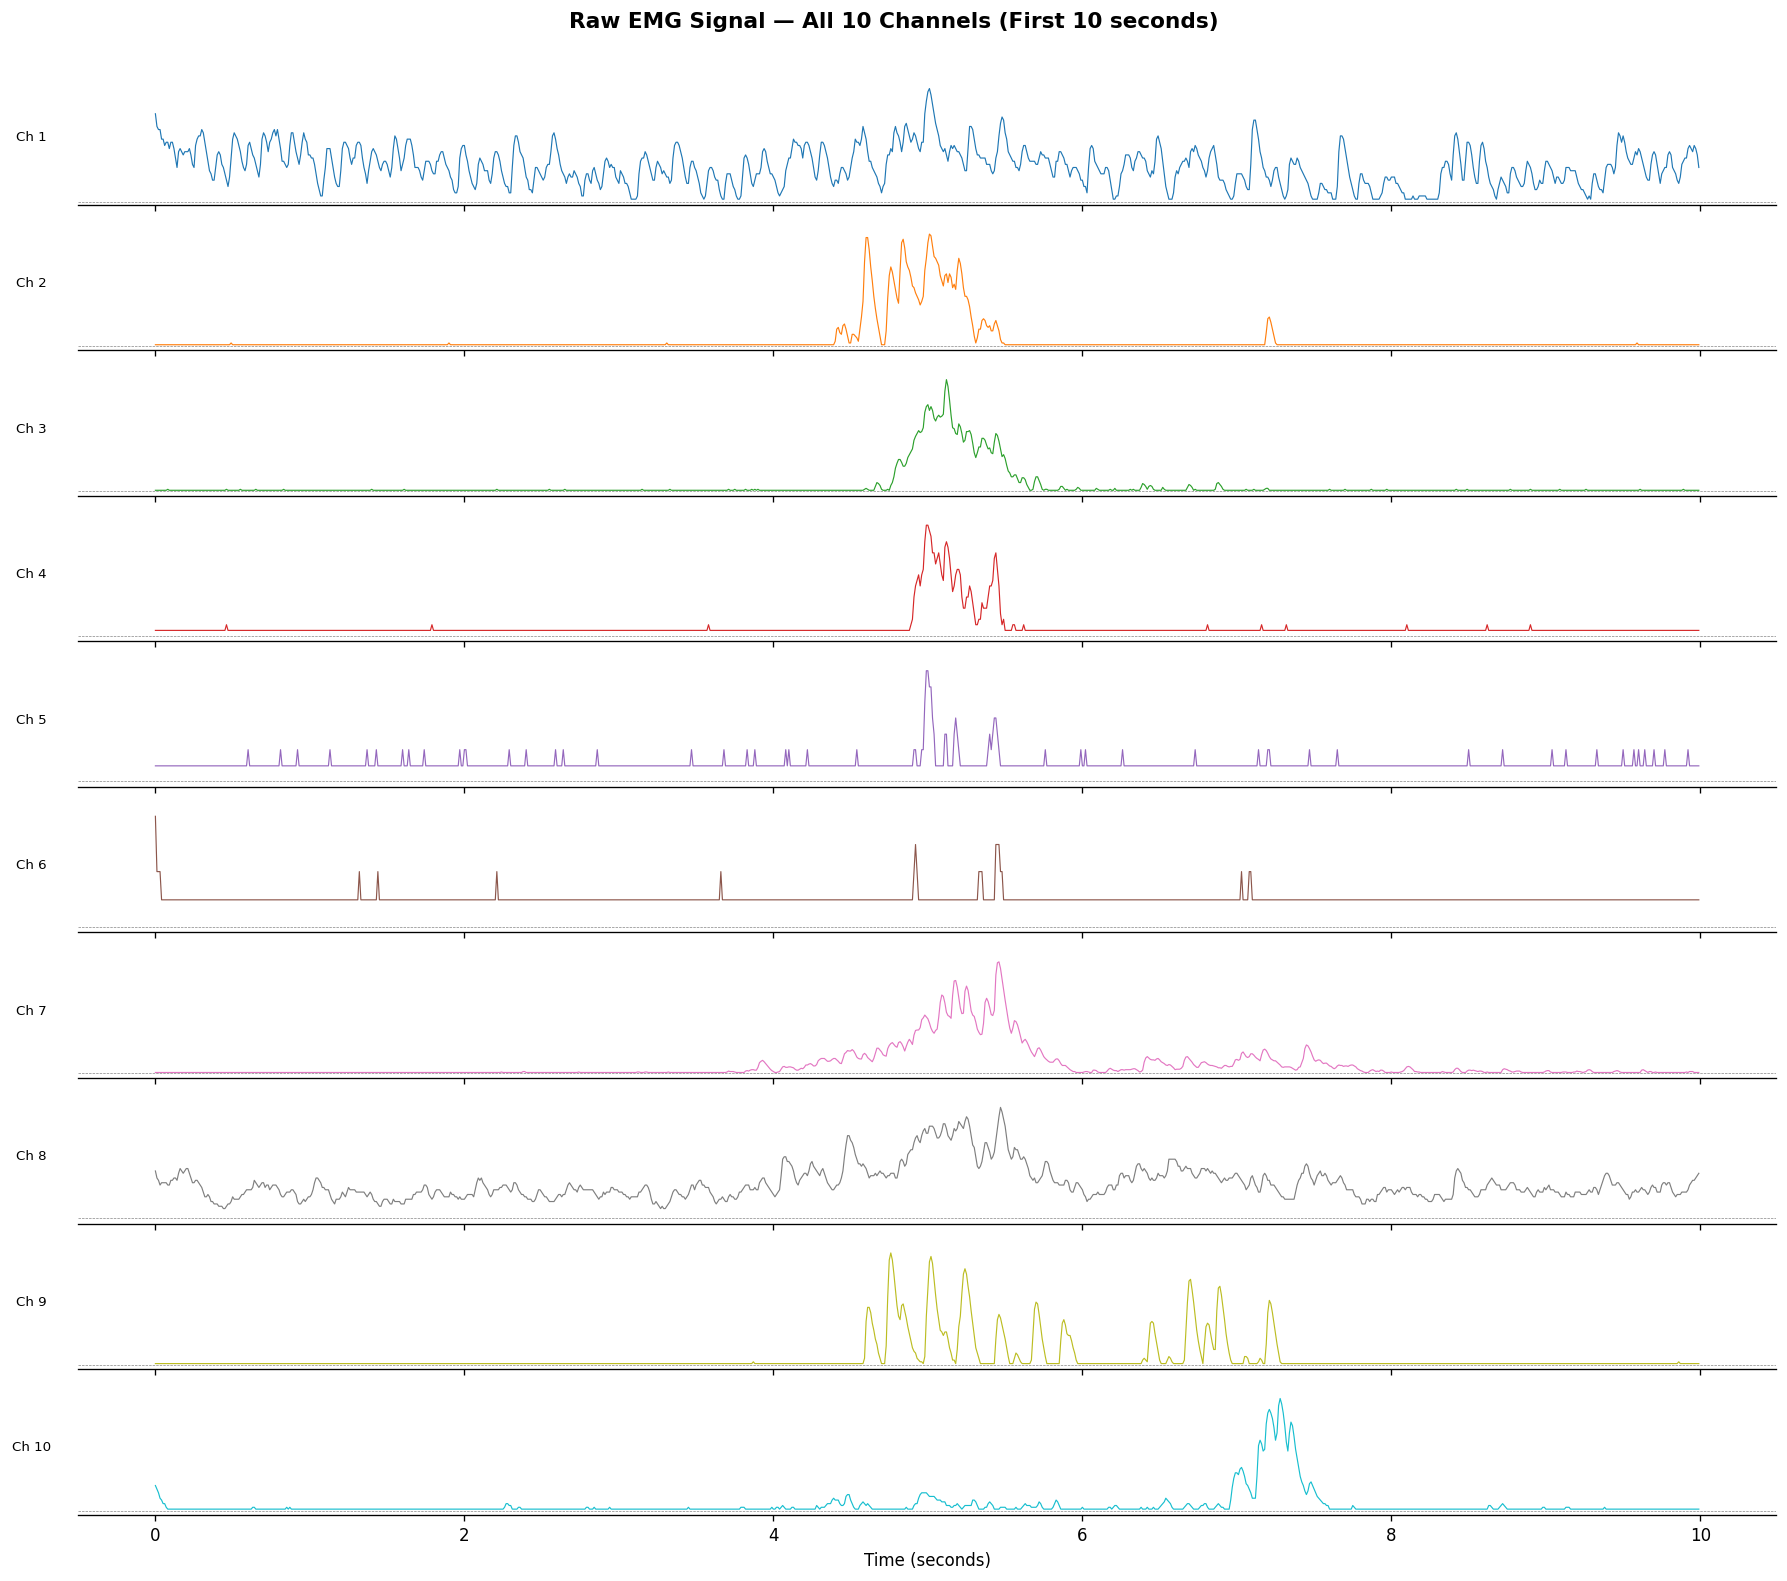

💡 Notice: Some channels are almost flat, others spike — different muscles, different roles


In [5]:
# Plot first 10 seconds of all 10 channels
end_sample = FS * 10
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, axes = plt.subplots(10, 1, figsize=(15, 13), sharex=True)
fig.suptitle('Raw EMG Signal — All 10 Channels (First 10 seconds)', 
             fontsize=13, fontweight='bold', y=1.01)

for i in range(10):
    axes[i].plot(t[:end_sample], emg[:end_sample, i],
                 color=colors[i], linewidth=0.7)
    axes[i].set_ylabel(f'Ch {i+1}', fontsize=8, rotation=0, labelpad=28)
    axes[i].set_yticks([])
    axes[i].spines[['top', 'right', 'left']].set_visible(False)
    axes[i].axhline(0, color='gray', linewidth=0.4, linestyle='--')

axes[-1].set_xlabel('Time (seconds)', fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/1_raw_emg.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Notice: Some channels are almost flat, others spike — different muscles, different roles')

---
## STEP 3 — Preprocessing

Raw EMG is messy and not directly usable. We clean it in 3 stages:

```
Raw Signal
    │
    ▼
① Bandpass Filter (20–45 Hz)    → removes noise outside the muscle signal range
    │
    ▼
② Rectification (|signal|)      → flip negative values to positive
    │
    ▼
③ RMS Envelope (200ms window)   → smooth it → shows muscle activation level
```

### Stage 1 — Bandpass Filter

**What is a bandpass filter?**  
It lets through only frequencies between 20 Hz and 450 Hz (the range where real muscle signals live), and blocks everything outside.

- **Below 20 Hz** → motion artifacts (your arm moving)
- **20–450 Hz** → actual muscle electrical activity ✅
- **Above 450 Hz** → electrical noise from the environment

> ⚠️ NinaPro DB1 samples at only 100 Hz, so our Nyquist limit is 50 Hz. The filter automatically adjusts to 20–45 Hz.

In [6]:
def bandpass_filter(signal, lowcut=20, highcut=450, fs=FS, order=4):
    """
    Bandpass filter: keeps only frequencies between lowcut and highcut Hz.
    - butter()   → designs the filter (calculates coefficients b, a)
    - filtfilt() → applies it forwards AND backwards (zero phase distortion)
    """
    nyq = fs / 2                          # Nyquist frequency = half the sampling rate
    highcut = min(highcut, nyq - 1)       # Can't filter above Nyquist
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal, axis=0) # axis=0 → filter along time axis

emg_filtered = bandpass_filter(emg)
print(f'✅ Bandpass filter applied')
print(f'   Before: signal range = [{emg.min():.4f}, {emg.max():.4f}]')
print(f'   After : signal range = [{emg_filtered.min():.4f}, {emg_filtered.max():.4f}]')
print(f'   → Values are now much smaller — noise removed')

✅ Bandpass filter applied
   Before: signal range = [0.0000, 4.6606]
   After : signal range = [-0.1635, 0.1425]
   → Values are now much smaller — noise removed


### Stage 2 — Rectification

**Why do we need this?**  
EMG signals oscillate between positive and negative values (muscles generate AC-like signals).  
If you try to average a signal that goes +0.003 and -0.003, you get 0 — which is wrong, the muscle WAS active!

**Solution:** Take the absolute value → all negatives become positive.  
```python
[-0.003, +0.004, -0.002]  →  [0.003, 0.004, 0.002]
```

In [7]:
emg_rectified = np.abs(emg_filtered)   # np.abs() = absolute value of every element

print('✅ Rectification done')
print(f'   Min value after rectification: {emg_rectified.min():.6f}  (always ≥ 0 now)')
print(f'   Max value after rectification: {emg_rectified.max():.6f}')

✅ Rectification done
   Min value after rectification: 0.000000  (always ≥ 0 now)
   Max value after rectification: 0.163497


### Stage 3 — RMS Envelope (Root Mean Square Smoothing)

**What is RMS?**  
Instead of looking at every individual sample, we slide a **200ms window** along the signal and compute the RMS (a type of average that handles fluctuations well) at each position.

**Result:** A smooth curve that shows the *level of muscle activation* over time — not the raw wiggly signal, but the overall trend.

```
Rectified: ▂▄█▆▂▁▂▄▆█▆▄▂▁...
Envelope:  ──╱▔▔╲────╱▔▔╲──   (smooth activation bumps)
```

> This step takes ~30 seconds because it processes 101,014 × 10 values.

In [8]:
def rms_envelope(signal, window):
    """
    Sliding window RMS:
    For each sample, look at 'window' samples around it,
    compute sqrt(mean(values^2)) → smooth amplitude envelope.
    """
    out = np.zeros_like(signal)
    for i in range(signal.shape[1]):           # loop over each of 10 channels
        for j in range(len(signal)):           # loop over each time step
            start = max(0, j - window // 2)
            end   = min(len(signal), j + window // 2)
            out[j, i] = np.sqrt(np.mean(signal[start:end, i] ** 2))
    return out

print(f'⏳ Computing RMS envelope (window = {WINDOW_MS}ms = {WINDOW_SAMPLES} samples)...')
emg_envelope = rms_envelope(emg_rectified, WINDOW_SAMPLES)
print(f'✅ RMS envelope computed — shape: {emg_envelope.shape}')

⏳ Computing RMS envelope (window = 200ms = 20 samples)...
✅ RMS envelope computed — shape: (101014, 10)


### Visualise All 3 Preprocessing Stages Together

Let's compare all 4 versions of the signal (raw, filtered, rectified, envelope) for **Channel 1** over the first 15 seconds.  
The coloured backgrounds show which gesture is being performed at each moment.

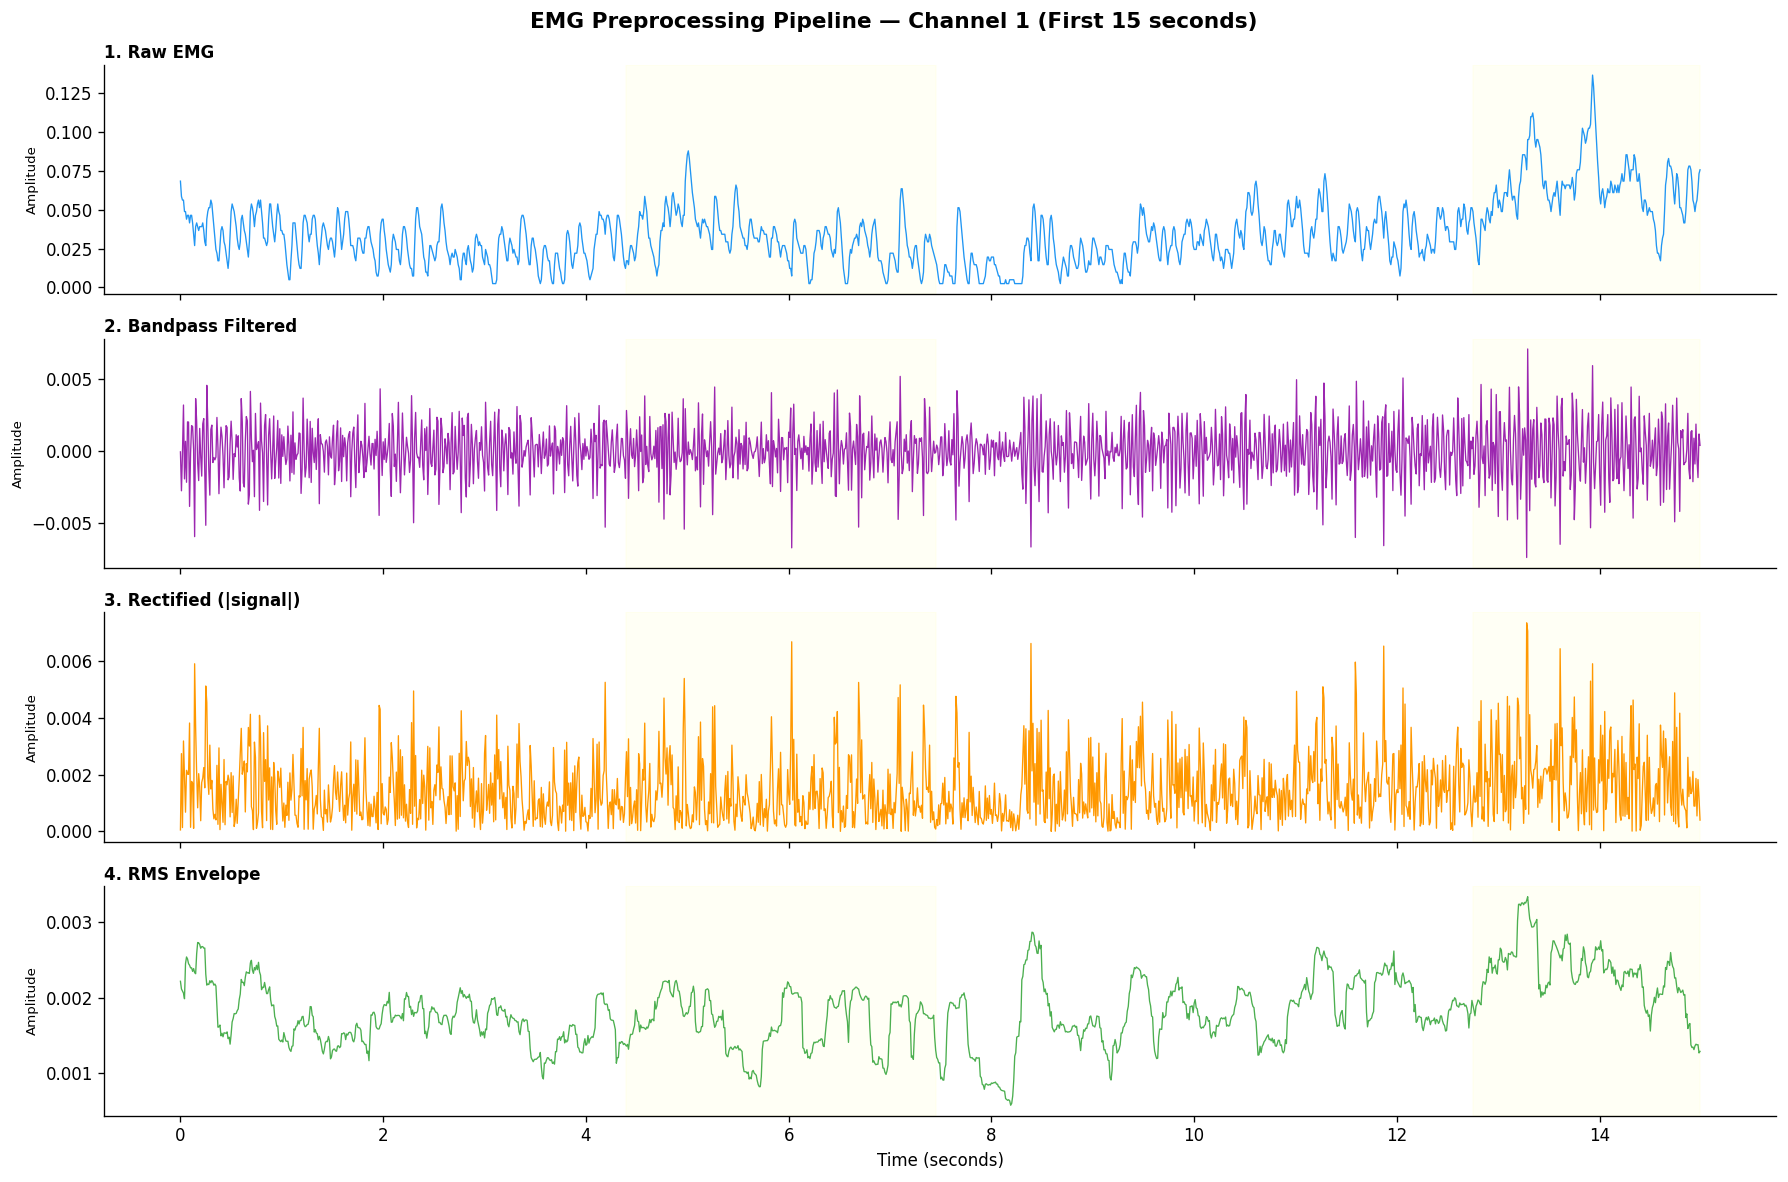

💡 The RMS envelope (green) is the cleanest — this is what we use for analysis


In [9]:
SHOW = slice(0, FS * 15)   # first 15 seconds
t_show = t[SHOW]
label_colors = plt.cm.Set3(np.linspace(0, 1, 13))

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
fig.suptitle('EMG Preprocessing Pipeline — Channel 1 (First 15 seconds)',
             fontsize=13, fontweight='bold')

stages = [
    (emg[SHOW, 0],           '1. Raw EMG',              '#2196F3'),
    (emg_filtered[SHOW, 0],  '2. Bandpass Filtered',    '#9C27B0'),
    (emg_rectified[SHOW, 0], '3. Rectified (|signal|)', '#FF9800'),
    (emg_envelope[SHOW, 0],  '4. RMS Envelope',          '#4CAF50'),
]

for ax, (sig, title, color) in zip(axes, stages):
    ax.plot(t_show, sig, color=color, linewidth=0.8)
    ax.set_title(title, fontsize=10, fontweight='bold', loc='left', pad=4)
    ax.set_ylabel('Amplitude', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    
    # Shade gesture windows
    prev, prev_idx = restim[0], 0
    for idx in range(1, FS * 15):
        if restim[idx] != prev or idx == FS * 15 - 1:
            if prev != 0:
                ax.axvspan(t[prev_idx], t[idx], alpha=0.12,
                           color=label_colors[int(prev)])
            prev, prev_idx = restim[idx], idx

axes[-1].set_xlabel('Time (seconds)', fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/2_preprocessing_stages.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 The RMS envelope (green) is the cleanest — this is what we use for analysis')

---
## STEP 4 — Segment by Gesture Label

The `restimulus` column tells us **which gesture** the subject was performing at every single time step.  

We use it to **cut out only the samples where a specific gesture is happening** — this is called segmentation.

We also filter by `rerepetition == 1` to only use the **first repetition** of each gesture (keeps it simple for now).

In [10]:
gesture_segments = {}
unique_gestures = [g for g in np.unique(restim) if g != 0]   # exclude rest (label 0)

print('✂️  Segmenting gestures (Repetition 1 only)...\n')
print(f'{"G#":<5} {"Gesture Name":<30} {"Samples":>8} {"Duration":>10}')
print('-' * 58)

for g in unique_gestures:
    # Find all time steps where this gesture AND repetition 1 is happening
    indices = np.where((restim == g) & (repet == 1))[0]
    
    if len(indices) > 0:
        gesture_segments[int(g)] = emg_envelope[indices, :]   # store envelope data
        name = GESTURE_NAMES.get(int(g), f'Gesture {int(g)}')
        print(f'G{int(g):<4} {name:<30} {len(indices):>8,} {len(indices)/FS:>8.1f}s')

print(f'\n✅ {len(gesture_segments)} gestures segmented')

✂️  Segmenting gestures (Repetition 1 only)...

G#    Gesture Name                    Samples   Duration
----------------------------------------------------------
G1    Small Finger Flexion                305      3.0s
G2    Ring Finger Flexion                 193      1.9s
G3    Middle Finger Flexion               524      5.2s
G4    Index Finger Flexion                348      3.5s
G5    Thumb Flexion                       452      4.5s
G6    Thumb + Index (Pinch)               293      2.9s
G7    Thumb + Middle                      246      2.5s
G8    Thumb + Ring                        211      2.1s
G9    Thumb + Small                       197      2.0s
G10   All Fingers Extended                458      4.6s
G11   Hook Grip                           186      1.9s
G12   Lateral Grip                        341      3.4s

✅ 12 gestures segmented


### Plot the EMG Envelope for Each Gesture

Each subplot = one gesture.  
Each coloured line = one of the 10 channels.  
The shape of these curves tells you **how that muscle fires during that gesture**.

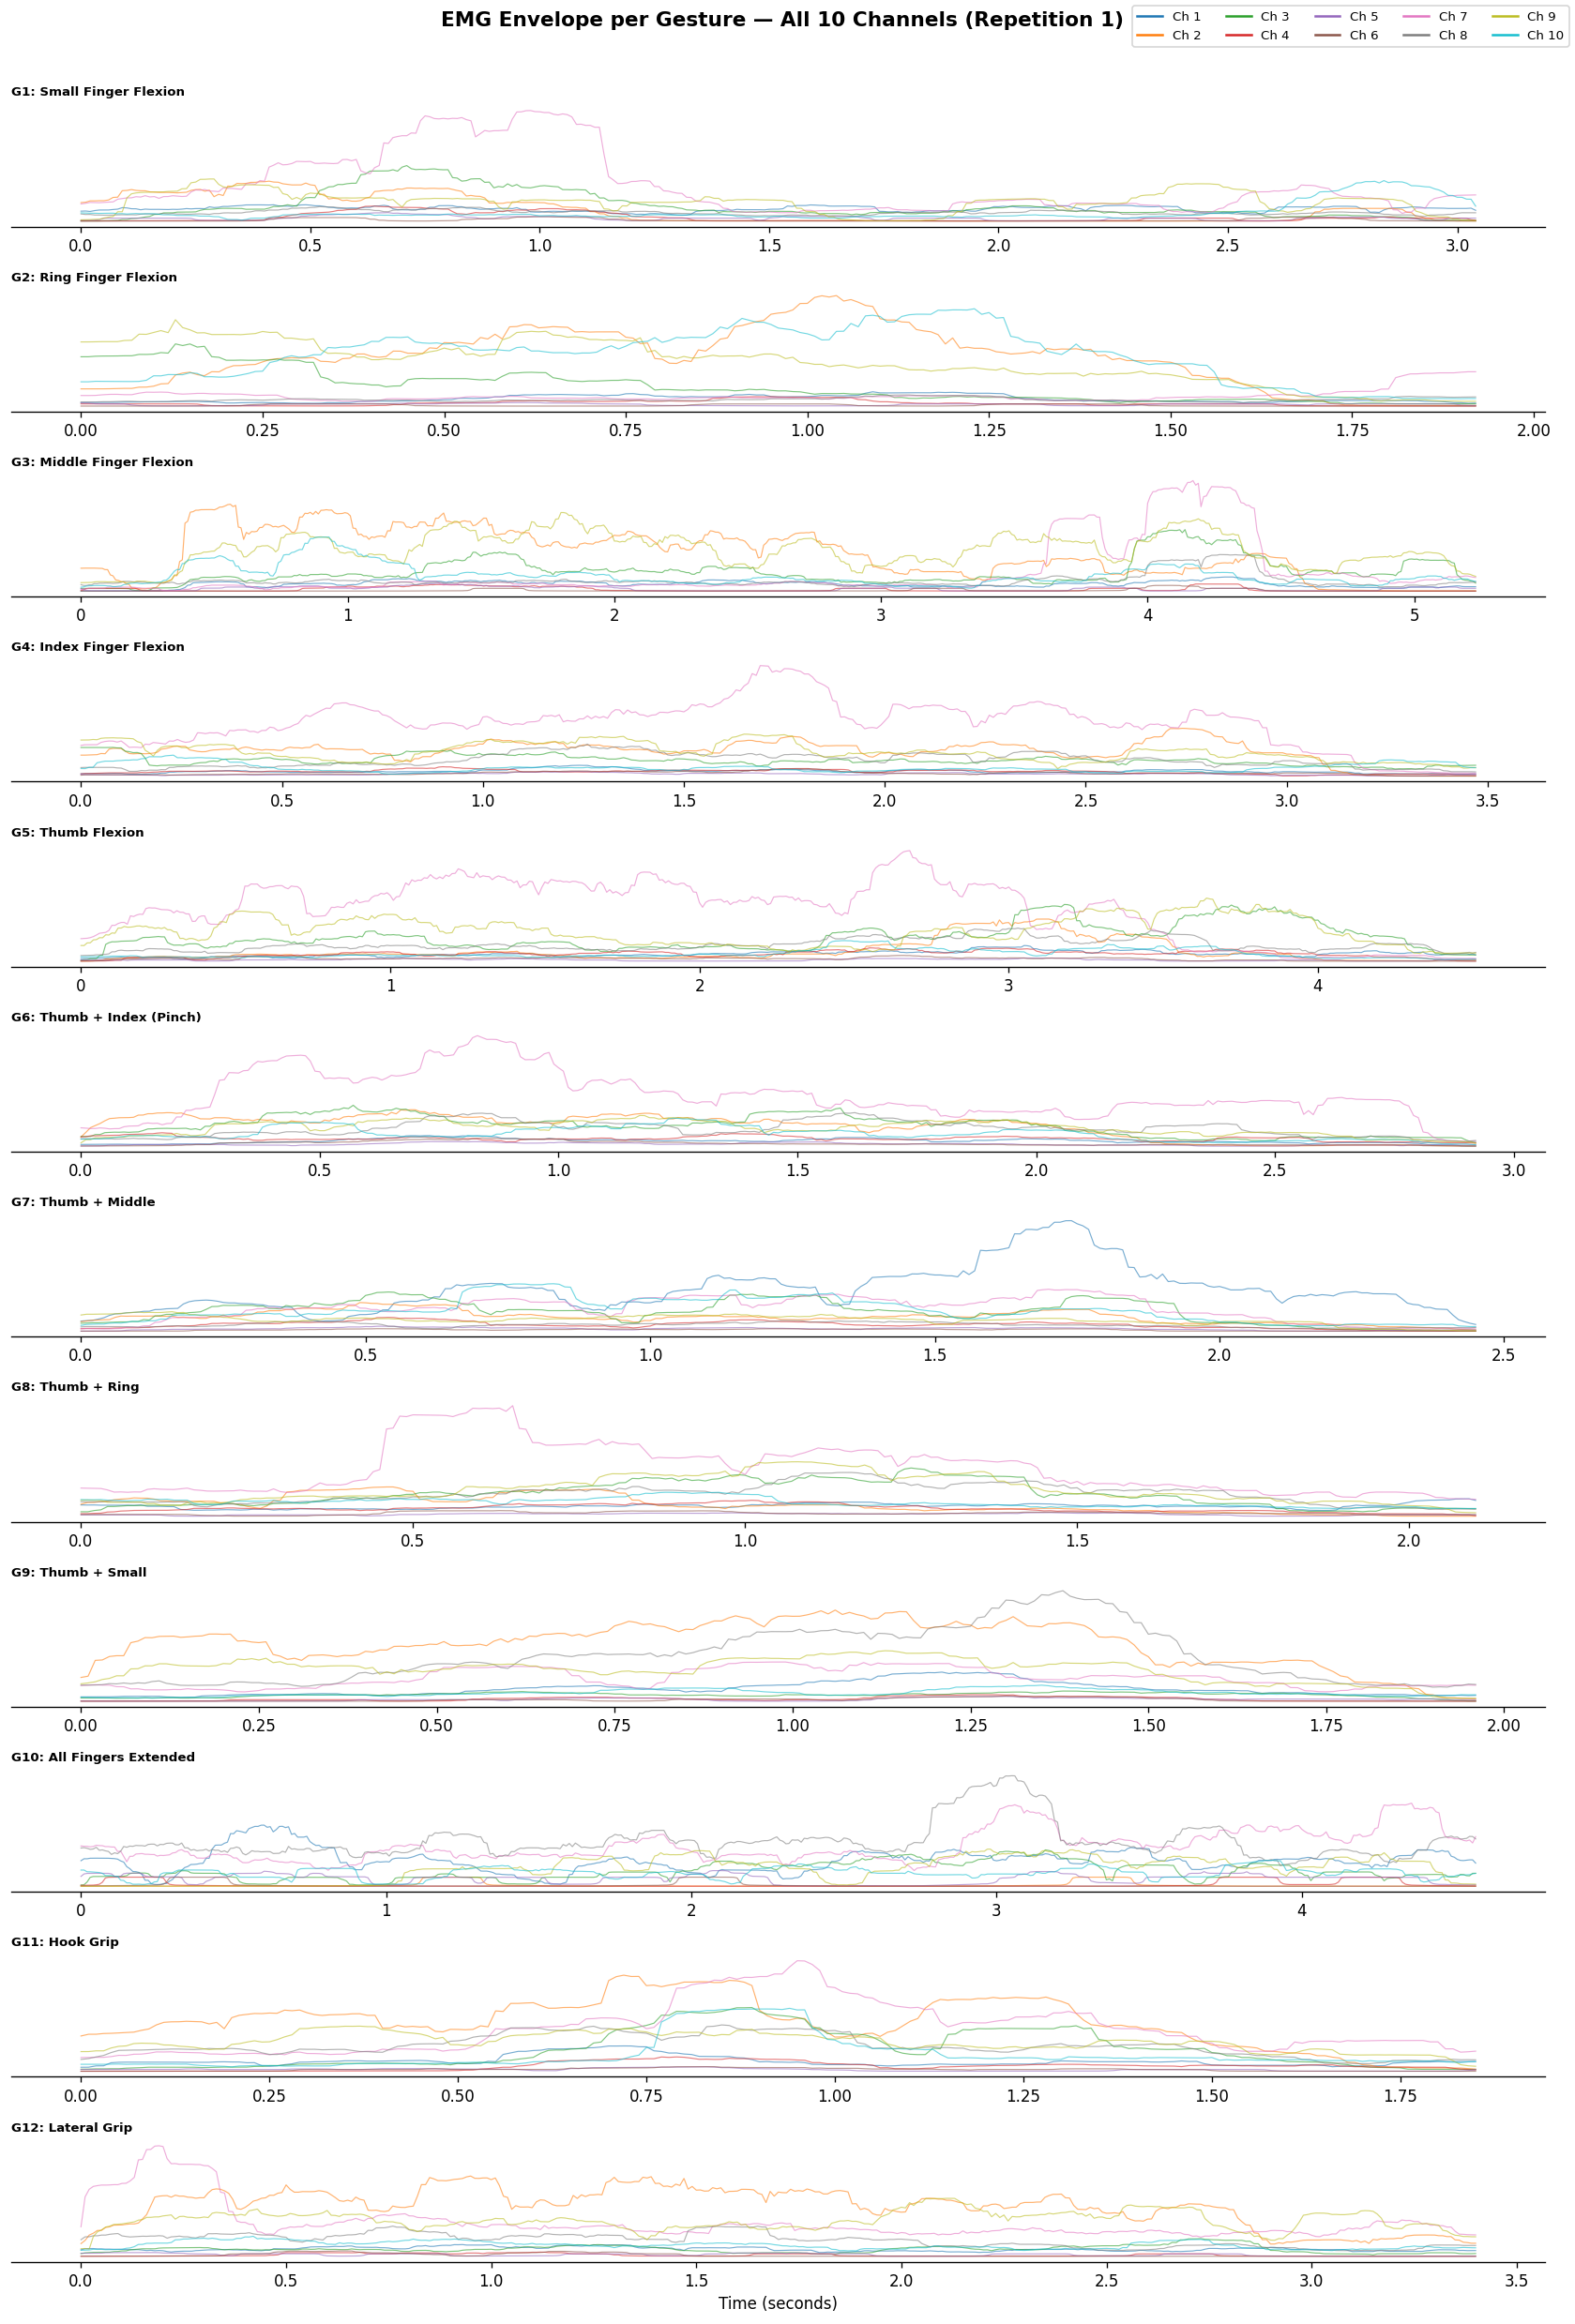

In [11]:
n = len(gesture_segments)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, axes = plt.subplots(n, 1, figsize=(14, n * 1.7), sharex=False)
fig.suptitle('EMG Envelope per Gesture — All 10 Channels (Repetition 1)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, (g_id, seg) in zip(axes, gesture_segments.items()):
    t_seg = np.arange(len(seg)) / FS
    for ch in range(10):
        ax.plot(t_seg, seg[:, ch], color=colors[ch], linewidth=0.7, alpha=0.6)
    ax.set_title(f'G{g_id}: {GESTURE_NAMES.get(g_id, "?")}'.strip(),
                 fontsize=8, fontweight='bold', loc='left')
    ax.set_yticks([])
    ax.spines[['top', 'right', 'left']].set_visible(False)

# Legend
handles = [plt.Line2D([0],[0], color=colors[i], linewidth=1.5, label=f'Ch {i+1}')
           for i in range(10)]
fig.legend(handles=handles, loc='upper right', ncol=5, fontsize=8)
axes[-1].set_xlabel('Time (seconds)', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/3_per_gesture_envelopes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## STEP 5 — Activation Heatmap

**The most useful summary visualisation.**

For each gesture, we compute the **mean RMS amplitude** across all its time steps for each channel.  
This gives us a single number per (gesture, channel) pair → plot it as a heatmap.

**How to read it:**
- **Rows** = gestures (G1–G12)
- **Columns** = EMG channels (Ch 1–10 = forearm muscles)
- **Brighter/darker colour** = higher muscle activation

**What to look for:**  
Different gestures should activate different channels — that's the whole point of EMG-based gesture recognition. If all gestures looked identical, you couldn't distinguish them!

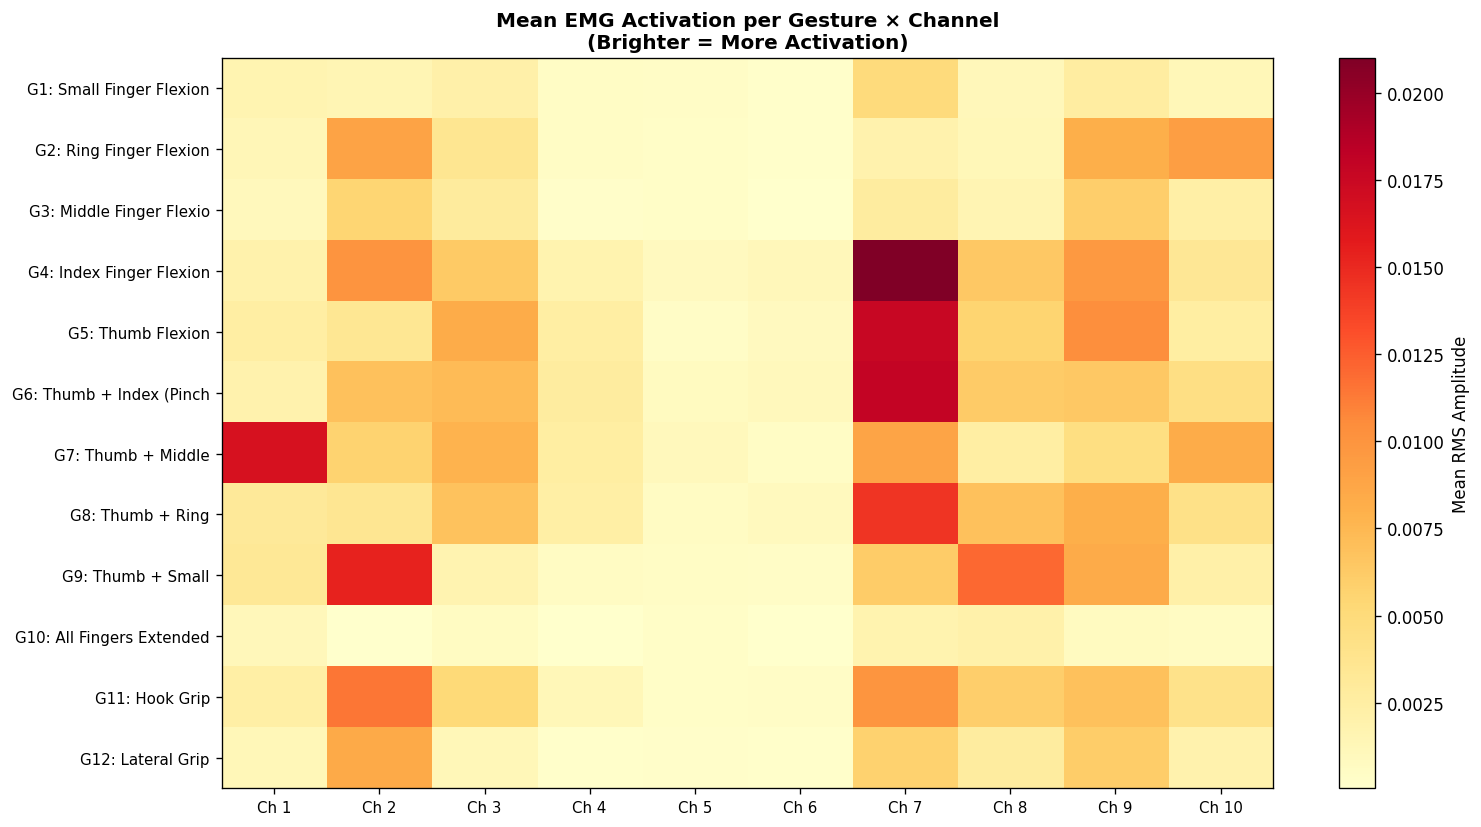

💡 Key insight: Each gesture has a unique "fingerprint" of channel activations
   This is exactly what a classifier will learn to distinguish!


In [12]:
# Build the activation matrix: shape = (num_gestures, 10)
mean_activations = np.zeros((len(gesture_segments), 10))
g_labels = []

for i, (g_id, seg) in enumerate(gesture_segments.items()):
    mean_activations[i] = np.mean(seg, axis=0)   # average over all time steps
    g_labels.append(f'G{g_id}: {GESTURE_NAMES.get(g_id, "?")[:20]}')

# Plot heatmap
fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(mean_activations, aspect='auto', cmap='YlOrRd', interpolation='nearest')

ax.set_xticks(range(10))
ax.set_xticklabels([f'Ch {i+1}' for i in range(10)], fontsize=9)
ax.set_yticks(range(len(g_labels)))
ax.set_yticklabels(g_labels, fontsize=9)
ax.set_title('Mean EMG Activation per Gesture × Channel\n(Brighter = More Activation)',
             fontsize=12, fontweight='bold')

plt.colorbar(im, ax=ax, label='Mean RMS Amplitude')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/4_activation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Key insight: Each gesture has a unique "fingerprint" of channel activations')
print('   This is exactly what a classifier will learn to distinguish!')

---
## STEP 6 — Final Summary & Key Numbers

In [13]:
print('=' * 60)
print('   PIPELINE SUMMARY')
print('=' * 60)
print(f'  Dataset       : NinaPro DB1')
print(f'  Subject       : S1 (Subject 1)')
print(f'  File          : S1_A1_E1.mat (Exercise 1)')
print(f'  Duration      : {emg.shape[0]/FS/60:.1f} minutes of recording')
print(f'  Sampling Rate : {FS} Hz')
print(f'  EMG Channels  : {emg.shape[1]} (forearm muscle sensors)')
print(f'  Gestures      : {len(gesture_segments)} hand gestures')
print()
print('  Preprocessing Steps Applied:')
print('  1. Bandpass Filter  → 20–45 Hz  (removes noise & motion artifacts)')
print('  2. Rectification    → |signal|  (flip negatives to positive)')
print(f'  3. RMS Envelope     → {WINDOW_MS}ms window  (smooth activation curve)')
print()
print('  Output Files:')
print(f'  📁 {OUTPUT_DIR}/')
print('     1_raw_emg.png               — all 10 channels, raw')
print('     2_preprocessing_stages.png  — raw → filter → rectify → envelope')
print('     3_per_gesture_envelopes.png — per-gesture EMG shape')
print('     4_activation_heatmap.png    — which muscles fire for which gesture')
print('=' * 60)

   PIPELINE SUMMARY
  Dataset       : NinaPro DB1
  Subject       : S1 (Subject 1)
  File          : S1_A1_E1.mat (Exercise 1)
  Duration      : 16.8 minutes of recording
  Sampling Rate : 100 Hz
  EMG Channels  : 10 (forearm muscle sensors)
  Gestures      : 12 hand gestures

  Preprocessing Steps Applied:
  1. Bandpass Filter  → 20–45 Hz  (removes noise & motion artifacts)
  2. Rectification    → |signal|  (flip negatives to positive)
  3. RMS Envelope     → 200ms window  (smooth activation curve)

  Output Files:
  📁 /Users/dewansh/Documents/Summer/HandsOn/output/emg/
     1_raw_emg.png               — all 10 channels, raw
     2_preprocessing_stages.png  — raw → filter → rectify → envelope
     3_per_gesture_envelopes.png — per-gesture EMG shape
     4_activation_heatmap.png    — which muscles fire for which gesture


---

## What's Next?

Now that you have clean, preprocessed EMG data, the typical next steps in a gesture recognition pipeline are:

| Step | What it involves |
|---|---|
| **Feature Extraction** | From each gesture window, extract features like Mean Absolute Value, Zero Crossing Rate, Waveform Length |
| **Train a Classifier** | Feed features into SVM, Random Forest, or a Neural Network to classify gestures |
| **Evaluate** | Check accuracy, confusion matrix across all 12 gestures |
| **Fuse with VR data** | Combine EMG predictions with hand skeleton data from Meta Quest — this is the actual research goal! |